# Optimizer profile: overview
Peak GPU memory and steady-state step time for every baseline and every Sven variant, per architecture, at the
training set point (`study == "methods"`). Produced by `experiments/optimizer_profile.py` on an exclusively reserved node.

* **Sven (Gram, hooks)**: per-layer kernel, no Jacobian. Not possible for the batch-statistics ResNet.
* **Sven (Gram, full $J$)**: one `jacrev`, the $B\times P$ Jacobian, its Gram matrix, `eigh`.
* **Sven (Gram, chunked)**: the same in parameter groups of $f\cdot P$ (here $f=0.25$).
* **Sven (classic, rand. SVD)**: the $B\times P$ Jacobian and a randomized-SVD pseudo-inverse (`randomized_v2`).

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
# $SV3_PROFILE_ROOT > profile_results_v3 (the re-measured profile) > profile_results_v2
ROOT = ph.results_root()         # prints which root it chose
df = ph.load_profiles(ROOT)      # one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)

study,batch_size,chunk_fraction,k,methods,microbatch,param_fraction,width
arch,,,,,,,
cifar_resnet18,16,5,8,16,10,26,0
mnist,36,6,15,17,21,48,0
mnist_width,0,0,0,0,0,0,91
nanogpt,25,5,12,17,15,18,0
nanogpt_width,0,0,0,0,0,0,55
polynomial,36,4,15,17,18,39,0
toy_1d,36,4,15,17,18,39,0


### Measurement quality
Step times are the **steady-state mean**: the first 20% of measured steps and any >3 MAD spike are dropped.
The panel below is the p90/p10 ratio of the raw per-step times for every configuration; anything above 1.3 is listed.

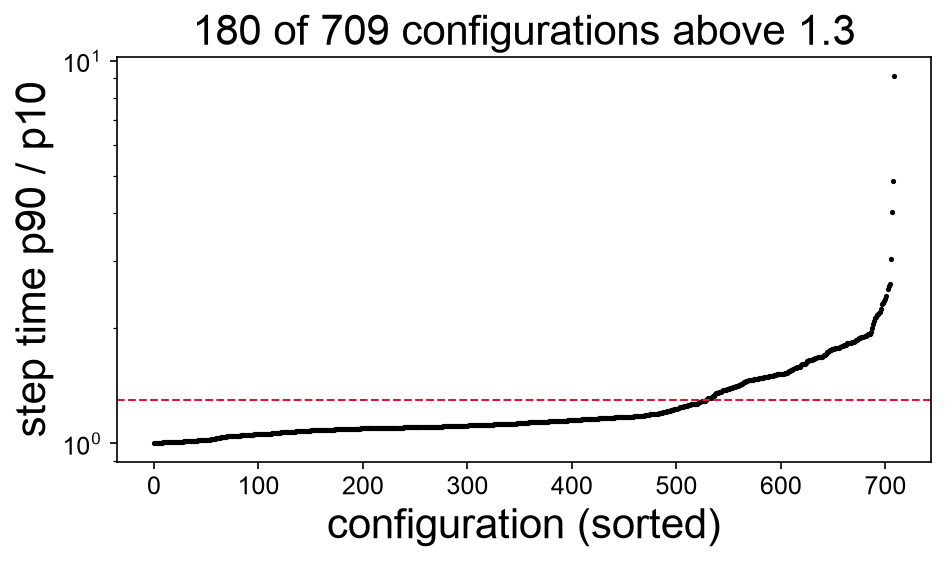

,arch,study,method,B,step_ms,step_ms_p10,step_ms_p90,steadiness
97,mnist,batch_size,SGD,512,3.723175,3.071994,4.009427,1.305155
383,nanogpt,microbatch,gram_full,64,99.735238,98.686031,129.407651,1.311307
215,mnist,param_fraction,gram_hooks,64,11.591527,11.561565,15.198797,1.314597
113,mnist,batch_size,gram_hooks,256,10.760954,10.309648,13.567571,1.316007
494,polynomial,batch_size,gram_hooks,256,11.878519,11.674544,15.369526,1.316499
18,cifar_resnet18,chunk_fraction,gram_chunked,128,470.148228,403.727011,534.100195,1.322924
496,polynomial,batch_size,gram_hooks,64,11.831747,11.237984,14.898071,1.325689
100,mnist,batch_size,classic,16,11.891759,10.841172,14.395923,1.327894
486,polynomial,batch_size,gram_full,128,17.583794,16.522839,22.271618,1.347929
476,polynomial,batch_size,SGD,256,3.479193,3.182458,4.311837,1.354876


In [2]:
fig, ax = plt.subplots(figsize=(7, 3.5))
unsteady = ph.plot_steadiness(df, ax)
ph.save(fig, 'qc_steadiness.pdf', PLOT_DIR); plt.show()
unsteady.head(20)

### Anything that did not run
Out-of-memory and analytically infeasible configurations are results, not failures; genuine errors are listed too.

In [3]:
ph.status_report(df)

,arch,study,method,B,pf,mask_mode,mb,width,status,error
0,cifar_resnet18,methods,HIG,128,1.00,none,1,NaN,infeasible,HIG output Jacobian is 57.3 GB (128x10 rows x ...
1,cifar_resnet18,param_fraction,classic,128,0.05,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
2,cifar_resnet18,param_fraction,classic,128,0.10,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
3,cifar_resnet18,param_fraction,classic,128,0.25,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
4,cifar_resnet18,param_fraction,classic,128,0.50,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
5,mnist,param_fraction,classic,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
6,mnist,param_fraction,gram_hooks,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
7,mnist_width,width,HIG,64,1.00,none,1,1024.0,error,_LinAlgError: cusolver error: CUSOLVER_STATUS_...
8,mnist_width,width,HIG,64,1.00,none,1,2048.0,oom,CUDA out of memory. Tried to allocate 23.89 Gi...
9,nanogpt,methods,HIG,64,1.00,none,1,NaN,infeasible,HIG output Jacobian is 1760.1 GB (64x8320 rows...


### Per-architecture method tables

In [4]:
tables = {}
for arch in ARCHS:
    tables[arch] = ph.method_table(df, arch)
    print(f"\n=== {ph.ARCH_TITLES.get(arch, arch)} ===")
    display(tables[arch])
    tables[arch].to_csv(f'{PLOT_DIR}/table_methods_{arch}.csv', index=False) if __import__('os').makedirs(PLOT_DIR, exist_ok=True) is None else None
    open(f'{PLOT_DIR}/table_methods_{arch}.tex', 'w').write(tables[arch].to_latex(index=False, na_rep='--', float_format='%.3g'))


=== Toy 1D MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.42,2.80,22.2,1.22,7.43,2.96,1.16,
1,"Sven (Gram, hooks)",11.64,3.13,18.9,1.04,4.89,6.71,1.12,
2,"Sven (Gram, full $J$)",15.33,4.12,18.9,1.04,7.71,7.48,1.11,
3,"Sven (Gram, chunked)",162.63,43.67,18.9,1.04,154.58,8.06,1.01,
4,SGD,3.50,0.94,18.1,1.00,NaN,NaN,1.09,
5,RMSprop,3.69,0.99,18.1,1.00,NaN,NaN,1.08,
6,AdamW,3.72,1.00,18.1,1.00,NaN,NaN,1.09,
7,Adam,3.75,1.01,18.1,1.00,NaN,NaN,1.15,
8,PolyakSGD,3.96,1.06,18.1,1.00,NaN,NaN,1.11,
9,Muon,5.07,1.36,18.1,1.00,NaN,NaN,1.04,



=== Polynomial MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.40,2.85,22.2,1.23,7.32,3.01,1.14,
1,"Sven (Gram, hooks)",11.53,3.16,18.9,1.04,4.78,6.67,1.10,
2,"Sven (Gram, full $J$)",15.16,4.15,18.9,1.04,7.62,7.46,1.08,
3,"Sven (Gram, chunked)",162.17,44.45,18.9,1.04,154.04,8.16,1.01,
4,SGD,3.49,0.96,18.1,1.00,NaN,NaN,1.15,
5,RMSprop,3.61,0.99,18.1,1.00,NaN,NaN,1.11,
6,AdamW,3.65,1.00,18.1,1.00,NaN,NaN,1.09,
7,Adam,3.65,1.00,18.1,1.00,NaN,NaN,1.12,
8,PolyakSGD,3.83,1.05,18.1,1.00,NaN,NaN,1.10,
9,Muon,5.32,1.46,18.1,1.00,NaN,NaN,1.01,



=== MNIST MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, hooks)",10.40,2.50,20.9,1.03,3.84,6.54,1.11,
1,"Sven (classic, rand. SVD)",14.45,3.47,48.5,2.39,9.26,5.25,1.61,
2,"Sven (Gram, full $J$)",17.62,4.23,48.6,2.40,8.64,8.89,1.48,
3,"Sven (Gram, chunked)",161.28,38.71,45.5,2.25,151.71,9.97,1.08,
4,SGD,3.94,0.95,19.9,0.98,NaN,NaN,1.24,
5,Adam,4.05,0.97,20.3,1.00,NaN,NaN,1.23,
6,PolyakSGD,4.07,0.98,19.9,0.98,NaN,NaN,1.11,
7,RMSprop,4.15,1.00,20.1,0.99,NaN,NaN,1.06,
8,AdamW,4.17,1.00,20.3,1.00,NaN,NaN,1.08,
9,Muon,5.34,1.28,20.2,1.00,NaN,NaN,1.02,



=== nanoGPT ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, hooks)",72.99,3.11,615.2,1.87,40.38,30.87,1.86,
1,"Sven (Gram, full $J$)",244.88,10.44,2893.1,8.81,211.01,33.69,1.18,
2,"Sven (classic, rand. SVD)",258.65,11.02,2893.1,8.81,240.51,10.73,1.17,
3,"Sven (Gram, chunked)",437.97,18.67,2625.4,7.99,404.98,33.02,1.06,
4,SGD,20.94,0.89,321.9,0.98,NaN,NaN,1.05,
5,RMSprop,22.65,0.97,325.2,0.99,NaN,NaN,1.04,
6,Adam,23.43,1.00,328.5,1.00,NaN,NaN,1.04,
7,AdamW,23.47,1.00,328.5,1.00,NaN,NaN,1.04,
8,PolyakSGD,28.87,1.23,321.9,0.98,NaN,NaN,1.08,
9,Muon,32.58,1.39,325.2,0.99,NaN,NaN,1.08,



=== CIFAR-10 ResNet18 ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, chunked)",474.29,19.77,6922.7,24.41,415.48,45.22,1.36,
1,"Sven (Gram, full $J$)",856.42,35.70,22977.7,81.02,760.35,94.70,2.18,
2,"Sven (classic, rand. SVD)",1110.91,46.31,23033.0,81.22,933.88,171.53,1.05,
3,SGD,22.12,0.92,191.0,0.67,NaN,NaN,1.04,
4,RMSprop,23.18,0.97,238.7,0.84,NaN,NaN,1.07,
5,Adam,23.94,1.00,282.6,1.00,NaN,NaN,1.07,
6,AdamW,23.99,1.00,283.6,1.00,NaN,NaN,1.09,
7,PolyakSGD,24.65,1.03,191.0,0.67,NaN,NaN,1.16,
8,Muon,24.83,1.03,283.6,1.00,NaN,NaN,1.14,
9,SOAP,43.69,1.82,312.8,1.10,NaN,NaN,1.18,


### Step time and peak memory, per architecture

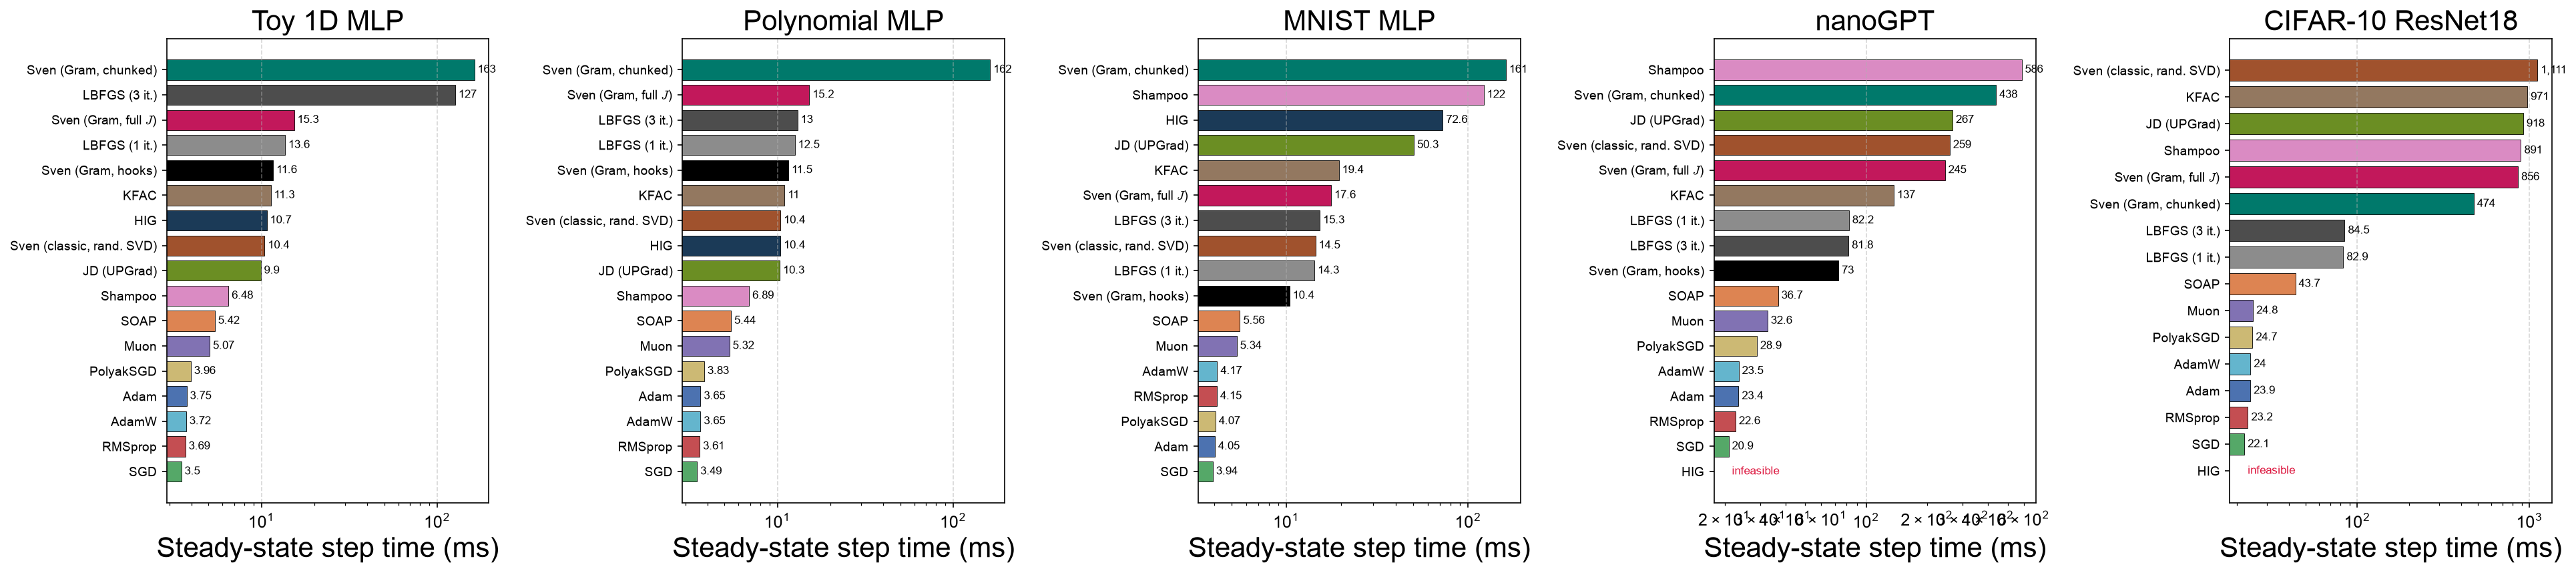

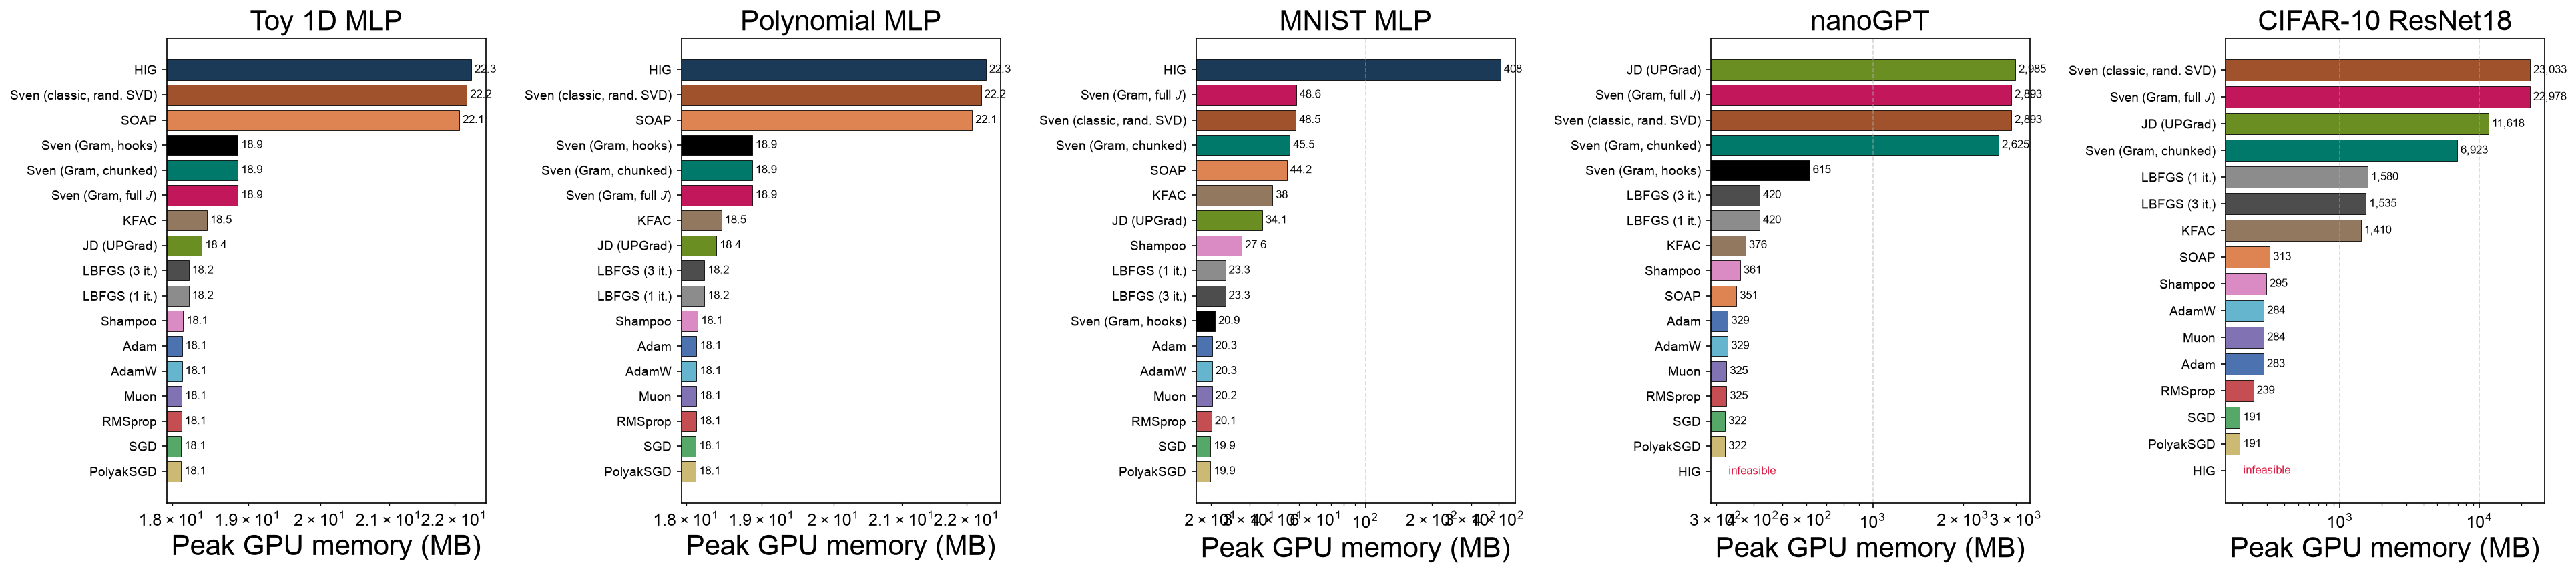

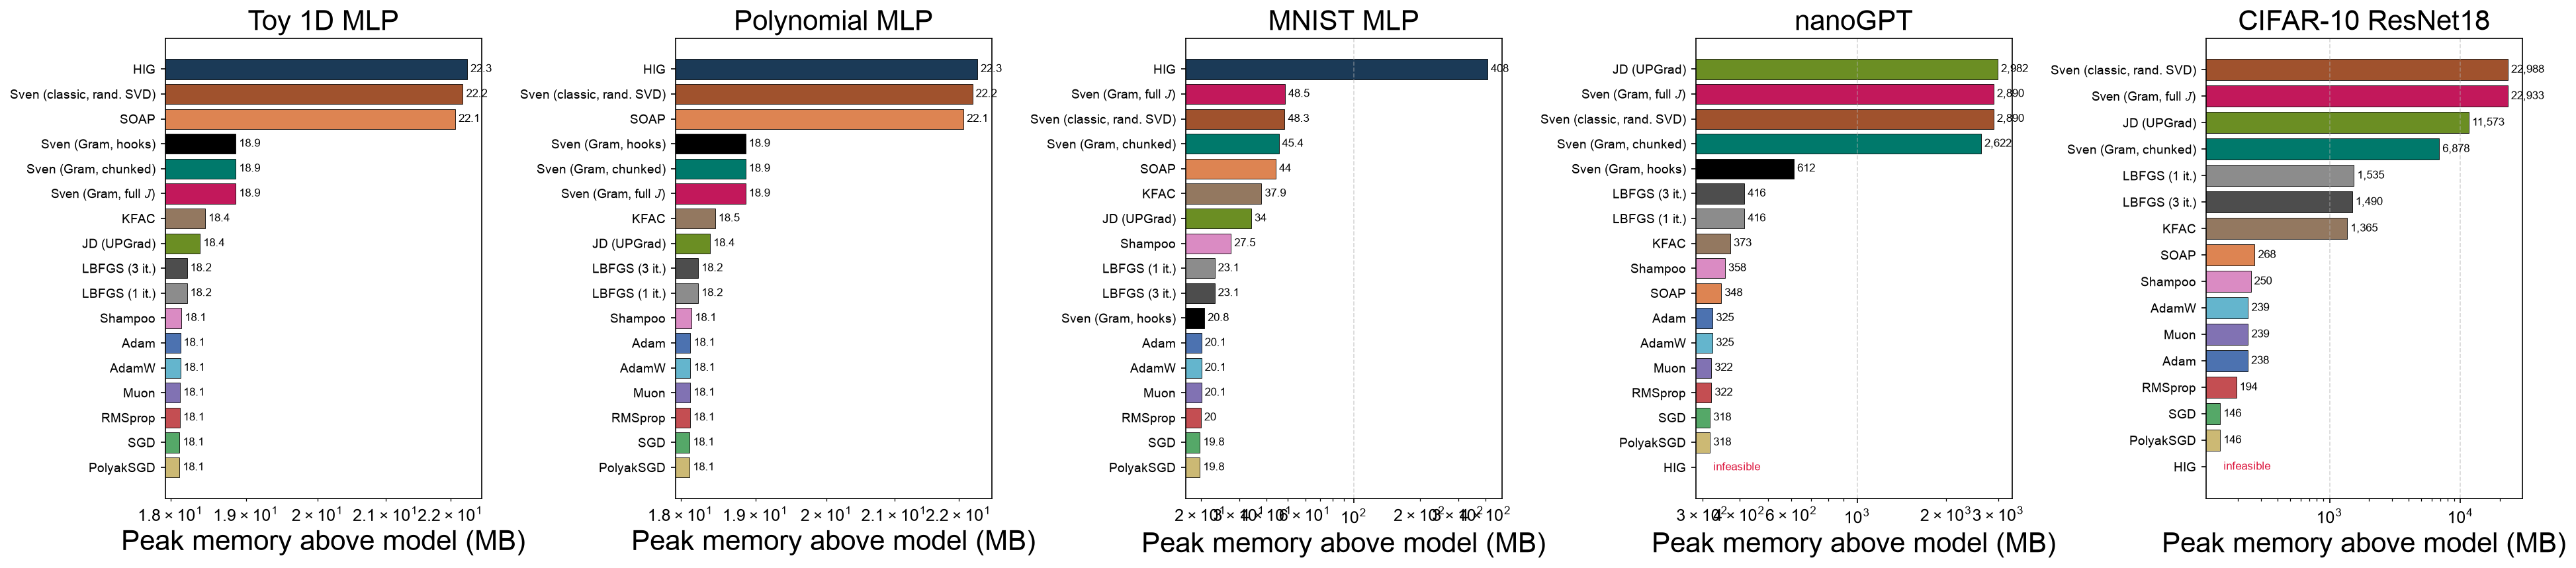

In [5]:
for value, fname in [('step_ms', 'methods_step_time'), ('peak_mb', 'methods_peak_memory'), ('overhead_mb', 'methods_memory_overhead')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5.2 * len(ARCHS), 6), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_method_bars(df, arch, ax, value=value)
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

### Cross-architecture summary
Step time relative to Adam and peak memory relative to SGD, same architecture and batch size.

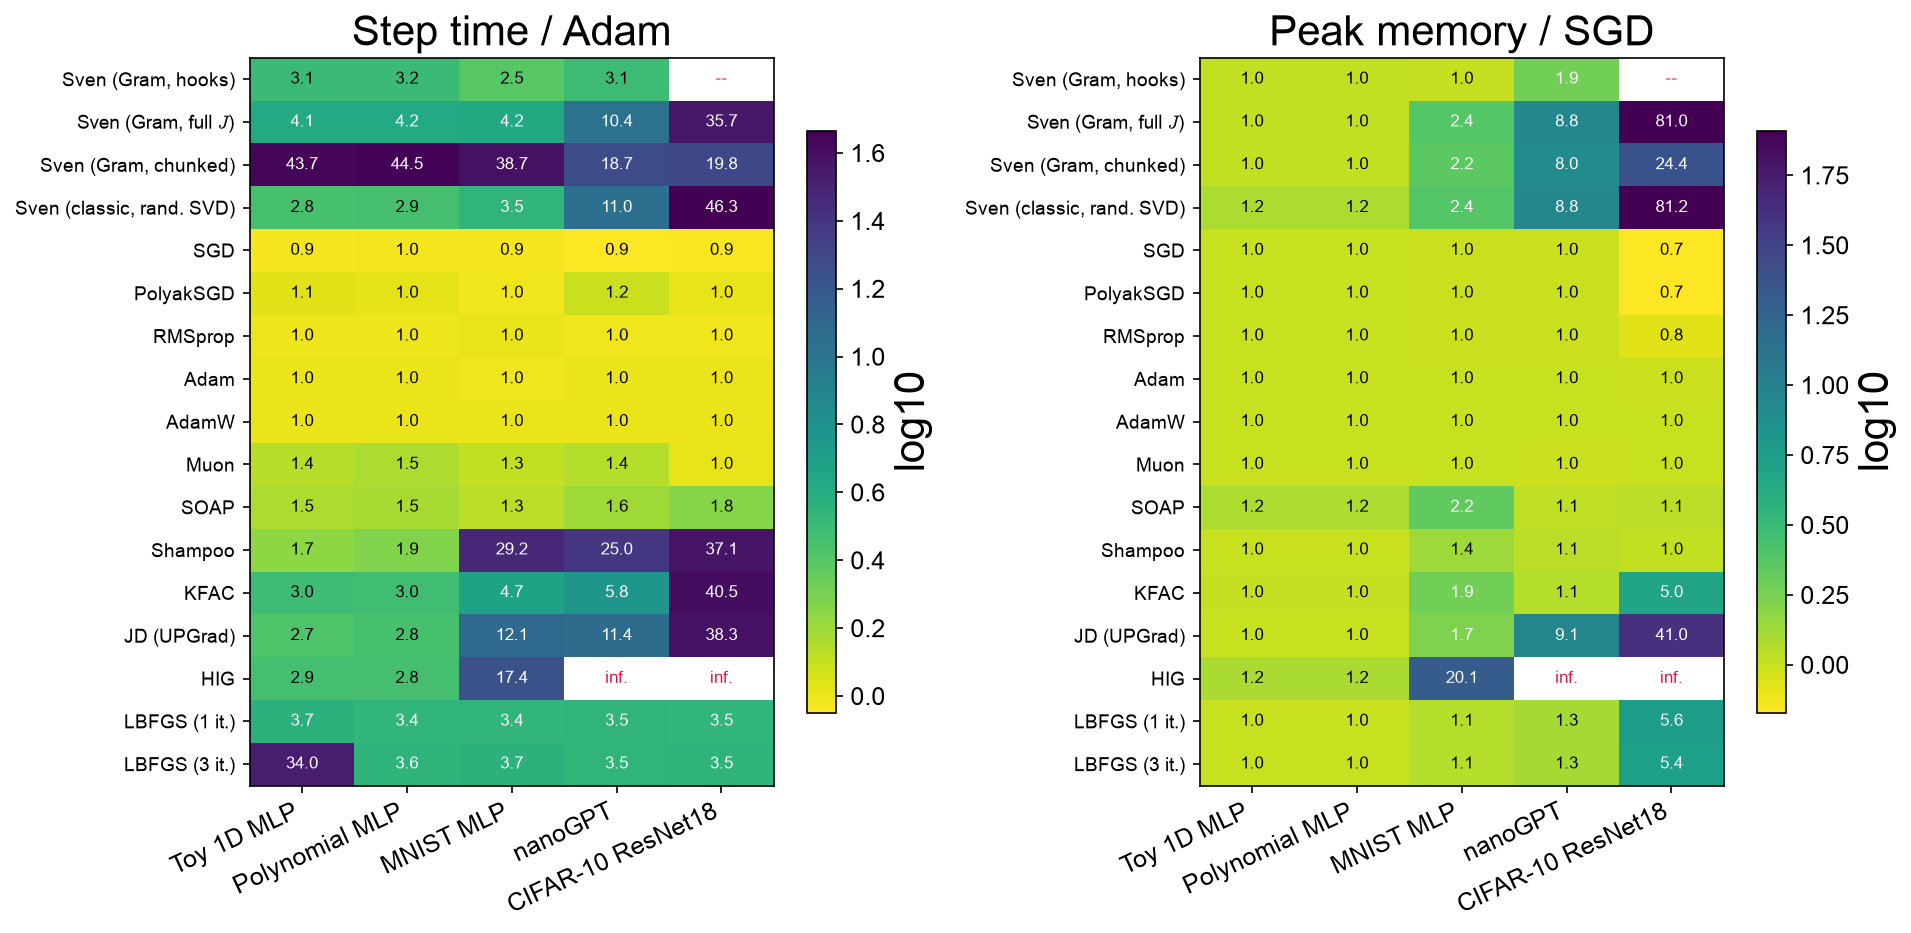

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, (value, title) in zip(axes, [('rel_time', 'Step time / Adam'), ('rel_mem', 'Peak memory / SGD')]):
    im = ph.plot_heatmap(df, ax, value=value); ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8, label='log10')
fig.tight_layout(); ph.save(fig, 'summary_heatmaps.pdf', PLOT_DIR); plt.show()

### Where a Sven step spends its time
Solid: capture (`loss_and_grad`: forward, Jacobian or Gram). Hatched: solve and apply (`optimizer.step`).

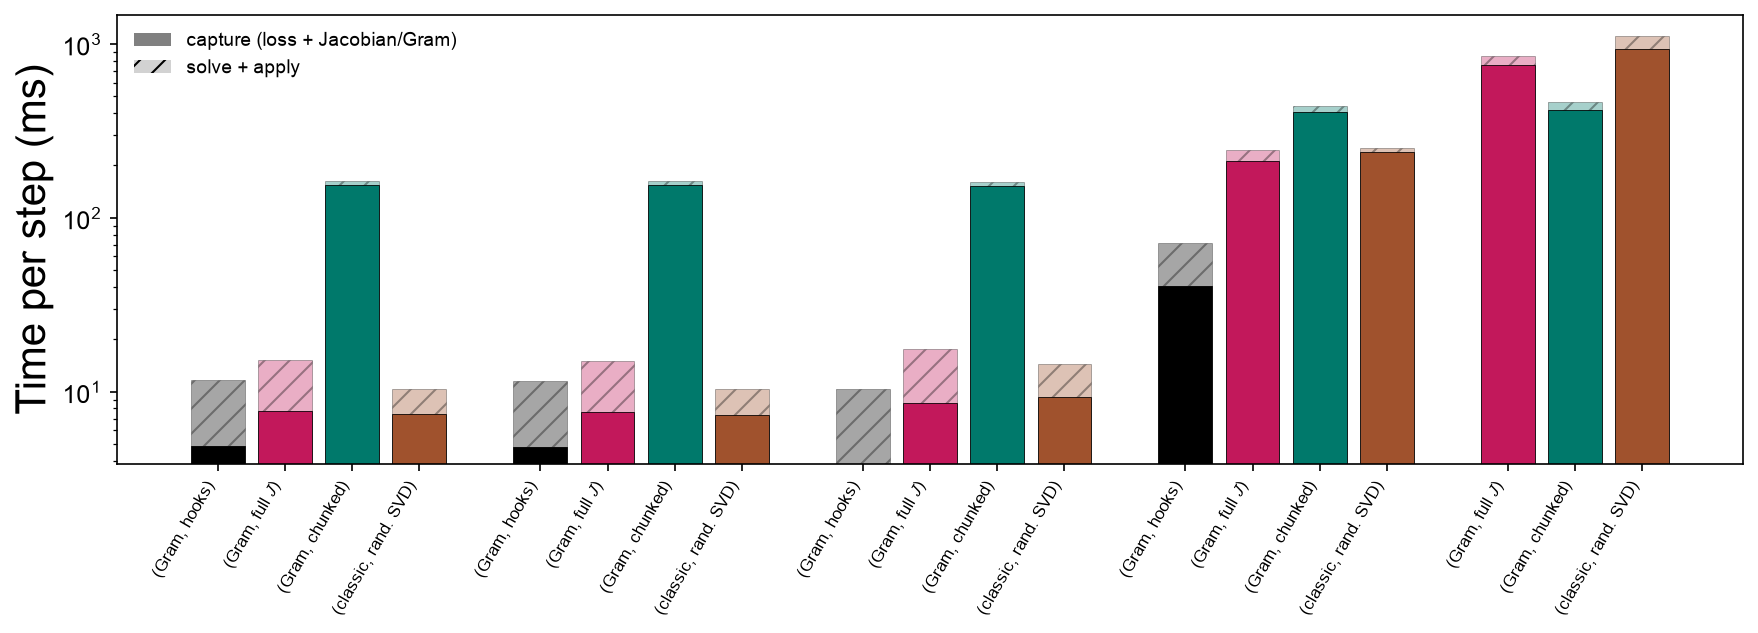

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ph.plot_phase_bars(df, ax)
fig.tight_layout(); ph.save(fig, 'sven_phase_breakdown.pdf', PLOT_DIR); plt.show()

### v2 vs v3: what the re-measurement changed
`profile_results_v2` (2026-09-17) was measured with Sven's per-step `torch.cuda.empty_cache()`, without
`expandable_segments`, and with the Gram wrapper freezing the BatchNorm statistics that the CIFAR scans keep
updating (`bn_mode: batch`, C-E2). `profile_results_v3` fixes all three (ANALYSIS_PLAN.md section 7.4), so the
Sven variants are expected to get FASTER -- up to ~4.5x for full capture on CIFAR -- while the baselines,
which never called `empty_cache`, should not move. A baseline that does move points at different hardware or a
busy node, not at the fix: check `gpu_old`/`gpu_new` below and the two `[calib]` lines in the profile job's log.

The cell is inert until v3 exists (it prints what is missing and stops), so this notebook runs either way.

In [ ]:
cmp = ph.compare_profiles()                      # v2 -> v3, joined on run_id
if len(cmp):
    print('GPU:', sorted(set(cmp.gpu_old.dropna())), '->', sorted(set(cmp.gpu_new.dropna())))
    print(f'{int(cmp.status_old.isna().sum())} configuration(s) only in v3, '
          f'{int(cmp.status_new.isna().sum())} only in v2')
    display(ph.compare_table(cmp, study='methods', value='step_ms'))
    display(ph.compare_table(cmp, study='methods', value='peak_mb', n=15))
    # the headline of the whole re-run: Sven's set-point step time, v2 -> v3
    sven = cmp[(cmp.study == 'methods') & cmp.method.isin(ph.SVEN)]
    display(sven.set_index(['arch', 'method'])[['step_ms_old', 'step_ms_new', 'step_ms_ratio',
                                                'peak_mb_old', 'peak_mb_new']].round(2))
cmp.head()